### In this jupyter notebook a LGBM model is trained and used as classifier. The trained model is udsed to predict the probability of sink or source on reactions from srtychnine pathways.

First, the necessairy libraries and modules for both the chemical applications and the machine learning are imported and the arrays of fingerprints and smiles are loaded.

In [1]:
from rdkit import Chem
from rdkit.Chem import inchi
import csv
import tqdm
import numpy as np
import networkx as nx
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import ParameterGrid
import csv
import tqdm


In [2]:
x = np.load("x.npy")

In [3]:
smis = np.load("smiles.npy")

In [4]:
print(x[0][:50])
print(x.shape)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]
(1434542, 4096)


In [5]:
print(smis[:10])
print(smis.shape)

[['C1(=CC=C(C=C1)OC)O[H]' 'C1(=CC=C(C=C1)OC)OC2=CC=C(C=C2)OC']
 ['C1(=CC=C(C=C1C[P](=O)(OCC)OCC)[S](F)(F)(F)(F)F)[N+](=O)[O-]'
  'C1(=CC=C(C=C1C=CC2=CC=CC=C2)[S](F)(F)(F)(F)F)[N+](=O)[O-]']
 ['C13=C(C=CC=C1C(C2=NC(=NC(=N2)OC)OC)C(N3[S](C(F)F)(=O)=O)=O)F'
  'C1(=C(C=CC=C1C(C2=NC(=NC(=N2)OC)OC)=O)F)N([H])[S](C(F)F)(=O)=O']
 ['C1=CC=CC(=C1CBr)CBr' 'C13=C(CCC2=C(CC1)C=CC=C2)C=CC=C3']
 ['CCCCCCCCCCCCCCCC(=O)Cl' 'CCCCCCCCCCCCCCC']
 ['C1(=CC(=CC(=C1[Mg]Br)C)C)C'
  'CC1=C(C(=O)NC2(CCCCC2)C(F)(F)F)C(=CC(=C1)C)C']
 ['C1(=CC=C(C(=C1)C(=O)O[H])I)O[H]' 'C1(=CC=C(C(=C1)C(=O)OC)I)O[H]']
 ['C1(=CC=C(C(=C1)C(=O)OC)I)O[H]'
  'C1(=CC=C(C(=C1)C(=O)OC)I)O[Si](C(C)C)(C(C)C)C(C)C']
 ['C1(=CC=C(C(=C1)C(=O)OC)I)O[Si](C(C)C)(C(C)C)C(C)C'
  'C(C)(C)[Si](OC=1C=CC(=C(C(=O)OC)C1)C=C)(C(C)C)C(C)C']
 ['C(C)(C)[Si](OC=1C=CC(=C(C(=O)OC)C1)C=C)(C(C)C)C(C)C'
  'C(C)(C)[Si](OC=1C=CC(=C(C1)CO)C=C)(C(C)C)C(C)C']]
(1434542, 2)


The array of fingerprints is than splilt into reactants and products for smiplifing the graph construction that is conducted  afterwards based on the equal reactant to the product of another reaction.

In [6]:
react = x[:,:2048]
prod = x[:,2048:]
n = x.shape[0]

In [7]:
print(react.shape)
print(prod.shape)

(1434542, 2048)
(1434542, 2048)


In [8]:
first_keys = [row.tobytes() for row in react]
second_keys = [row.tobytes() for row in prod]

In [9]:
from collections import defaultdict

first_map = defaultdict(list)
second_map = defaultdict(list)

for i in range(n):
    first_map[first_keys[i]].append(i)
    second_map[second_keys[i]].append(i)

In [10]:
edges = []

# first[i] == second[j]
for key in first_map:
    if key in second_map:
        for i in first_map[key]:
            for j in second_map[key]:
                if i != j:
                    edges.append((j, i))

# second[i] == first[j]
for key in second_map:
    if key in first_map:
        for i in second_map[key]:
            for j in first_map[key]:
                if i != j:
                    edges.append((i, j))

In [11]:
print(len(edges))

4381768


In [12]:
G = nx.DiGraph(edges)

In [13]:
in_deg  = dict(G.in_degree())
out_deg = dict(G.out_degree())
tot_deg = {n: in_deg[n] + out_deg[n] for n in G.nodes()}

top_node = max(tot_deg, key=tot_deg.get)
print(f"Most connected node : {top_node}")
print(f"  in-degree         : {in_deg[top_node]}")
print(f"  out-degree        : {out_deg[top_node]}")
print(f"  total degree      : {tot_deg[top_node]}")


Most connected node : 294551
  in-degree         : 35
  out-degree        : 2371
  total degree      : 2406


Nodes are than sorted based on incoming and outgoing degree and top 10 000 for each of the cathegories are selected for the final dataset. A classification array of the target features y is constructed with 1 representing reaction with higher incoming degree and 0 those with high outgoing degree.

In [14]:
in_deg = G.in_degree()

in_sorted = sorted(in_deg, key = lambda x:x[1], reverse = True)

print(in_sorted[:20])

[(83775, 109), (166181, 109), (252829, 109), (1043533, 109), (1394284, 109), (13323, 85), (98065, 85), (98096, 85), (154572, 85), (248687, 85), (555045, 85), (555046, 85), (588701, 85), (696629, 85), (993174, 85), (1052969, 85), (1156033, 85), (1175493, 85), (1275244, 85), (19778, 84)]


In [15]:
out_deg = G.out_degree()

out_sorted = sorted(out_deg, key = lambda x:x[1], reverse = True)

print(out_sorted[:20])

[(294551, 2371), (6553, 1124), (62063, 1124), (64774, 1124), (155114, 1124), (172045, 1124), (299653, 1124), (477184, 1124), (530773, 1124), (16333, 1017), (19518, 1017), (22367, 1017), (24266, 1017), (39555, 1017), (43481, 1017), (180274, 1017), (299041, 1017), (384696, 1017), (391492, 1017), (464316, 1017)]


In [16]:
print(len(out_sorted))

1111125


In [17]:
x = 0
in_nodes = []
in_rp = []

top_out_nodes = {n[0] for n in out_sorted[:10000]}
for n in in_sorted:
    if x == 10000:
        break
    if n[0] not in top_out_nodes:
        in_nodes.append(n[0])
        in_rp.append((react[n[0]], prod[n[0]]))
        x = x+1


In [18]:
x = 0
out_nodes = []
out_rp = []
top_in_nodes = {n[0] for n in in_sorted[:10000]}
for n in out_sorted:
    if x == 10000:
        break
    if n[0] not in top_in_nodes:
        out_nodes.append(n[0])
        out_rp.append((react[n[0]], prod[n[0]]))
        x = x+1
    

In [19]:
in_out_sub= in_nodes.copy()
in_out_sub.extend(out_nodes)
print(len(in_out_sub))
H = G.subgraph(in_out_sub)


20000


In [20]:
y = np.zeros(20000, dtype = int)
y[:10000] = 1
# 1 = in 0 = out

print(y.shape)

(20000,)


In [21]:
sub_rp = in_rp.copy()
sub_rp.extend(out_rp)
print(len(sub_rp))
sub_rp_arr = np.array(sub_rp)
print(sub_rp_arr.shape)

20000
(20000, 2, 2048)


In [22]:
subSetArr = np.array(sub_rp)
subSetArr =  np.concatenate([subSetArr[:, 0, :], subSetArr[:, 1, :]], axis=1)
print(subSetArr.shape)

(20000, 4096)


In [23]:
import pandas as pd
subSetArr = pd.DataFrame(subSetArr)

The dataset is than split into train, test and validation subsets.

In [24]:
Xtrain, Xtest, ytrain, ytest = train_test_split(subSetArr, y, test_size=0.4, random_state=666) 
display(Xtrain.shape)
display(ytrain.shape)
display(Xtest.shape)
display(ytest.shape)

Xval, Xtest, yval, ytest = train_test_split(Xtest, ytest, test_size=0.5, random_state=666) 
display(Xval.shape)
display(yval.shape)
display(Xtest.shape)
display(ytest.shape)

(12000, 4096)

(12000,)

(8000, 4096)

(8000,)

(4000, 4096)

(4000,)

(4000, 4096)

(4000,)

In [25]:
print(np.sum(yval==0))
print(np.sum(yval==1))

2008
1992


In the following cells various atempts at using the LGBM classifier were executed each tiime with different setting or method.The parameter grid is udes to determinate the best performing hyperparameters. A cross validation is also performed.

In [26]:
import lightgbm as lgbm
lgb = lgbm.LGBMClassifier(verbose = -1)
lgb.fit(Xtrain, ytrain)
print('parameters:',lgb.get_params())
print('train accuracy: {0:.6f}'.format(metrics.accuracy_score(ytrain, lgb.predict(Xtrain))))
print('validation accuracy: {0:.6f}'.format(metrics.accuracy_score(yval, lgb.predict(Xval))))


ypred = lgb.predict(Xval)
print(confusion_matrix(yval, ypred))

parameters: {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0, 'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 100, 'n_jobs': None, 'num_leaves': 31, 'objective': None, 'random_state': None, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0, 'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1}
train accuracy: 0.995667
validation accuracy: 0.986750
[[1982   26]
 [  27 1965]]


In [29]:
param_grid = {
    'num_leaves': [16, 32, 64], 
    'max_depth': [-1, 5, 10],
    'learning_rate': [0.005, 0.01, 0.1],
    'n_estimators' : [50, 100, 150],
    'min_child_samples': [2, 10, 50],
    'subsample': [0.5, 1],
    'colsample_bytree': [0.5, 1]
}
param_comb = ParameterGrid(param_grid)

In [30]:

val_acc = []
for params in tqdm.tqdm(param_comb):
    lgb = lgbm.LGBMClassifier(num_leaves = params['num_leaves'], max_depth=params['max_depth'], learning_rate=params['learning_rate'], n_estimators=params['n_estimators'], min_child_samples=params['min_child_samples'], subsample=params['subsample'], colsample_bytree=params['colsample_bytree'])
    lgb.fit(Xtrain, ytrain)
    val_acc.append(metrics.accuracy_score(yval, lgb.predict(Xval)))

best_params = param_comb[np.argmax(val_acc)]
best_params

100%|██████████████████████████████████████████████████████████████████████████████| 972/972 [1:06:10<00:00,  4.09s/it]


{'subsample': 0.5,
 'num_leaves': 64,
 'n_estimators': 150,
 'min_child_samples': 2,
 'max_depth': -1,
 'learning_rate': 0.1,
 'colsample_bytree': 0.5}

In [27]:
import lightgbm as lgbm
lgb = lgbm.LGBMClassifier(num_leaves = 64, max_depth=-1, learning_rate=0.1, n_estimators=150, min_child_samples=2, subsample=0.5, colsample_bytree=0.5)
lgb.fit(Xtrain, ytrain)
print('train accuracy: {0:.6f}'.format(metrics.accuracy_score(ytrain, lgb.predict(Xtrain))))
print('validation accuracy: {0:.6f}'.format(metrics.accuracy_score(yval, lgb.predict(Xval))))


ypred = lgb.predict(Xval)
print(confusion_matrix(yval, ypred))

train accuracy: 0.999833
validation accuracy: 0.994500
[[1994   14]
 [   8 1984]]


The misclassifications were visualized in the following two cells.

In [28]:
val_df = Xval.copy()
val_df["true"] = yval
val_df["pred"] = ypred

misclassified = val_df[val_df["true"] != val_df["pred"]]

print(misclassified)

       0  1  2  3  4  5  6  7  8  9  ...  4088  4089  4090  4091  4092  4093  \
18031  0  0  0  0  0  0  0  0  0  0  ...     0     0     0     0     0     0   
13611  0  0  0  0  0  0  0  0  0  0  ...     0     0     0     0     0     0   
9356   0  1  0  0  0  0  0  0  0  0  ...     0     0     0     0     0     0   
18409  0  0  0  0  0  0  0  0  0  0  ...     0     0     0     0     0     0   
3128   0  0  0  0  0  0  0  0  0  0  ...     0     0     0     0     0     0   
15597  0  0  0  0  0  0  0  0  0  0  ...     0     0     0     0     0     0   
13462  0  0  0  0  0  0  0  0  0  0  ...     0     0     0     0     0     0   
12168  0  0  0  0  0  0  0  0  0  0  ...     0     0     0     0     0     0   
18395  0  1  0  0  0  0  0  0  0  0  ...     0     0     0     0     0     0   
5647   0  0  0  0  0  0  0  0  0  0  ...     0     0     0     0     0     0   
18991  0  0  0  0  0  0  0  0  0  0  ...     0     0     0     0     0     0   
9037   0  0  0  0  0  0  0  0  0  0  ...

In [29]:
print(smis[in_out_sub[18031]])
print(smis[in_out_sub[13611]])
print(smis[in_out_sub[18409]])
print(smis[in_out_sub[15597]])
print(smis[in_out_sub[13462]])
print("....................................")
print(smis[in_out_sub[9356]])
print(smis[in_out_sub[3128]])
print(smis[in_out_sub[5647]])
print(smis[in_out_sub[9037]])
print(smis[in_out_sub[3127]])


['C(CO)O' '[Si](C)(C)(C(C)(C)C)OCCO']
['C(C)(C)(C)OC(=O)N1CCC(C(=O)OCC)CC1'
 'C(C)OC(CC(=O)C1CCN(CC1)C(=O)OC(C)(C)C)=O']
['C(C)(C)(C)OC(=O)N1CC2=CC(=C(C=C2CC1)[N+](=O)[O-])Br'
 'NC=1C=C2CCN(CC2=CC1)C(=O)OC(C)(C)C']
['C(C)(C)(C)OC(=O)N1CCC(CC1)C#CCO' 'C(C)(C)(C)OC(=O)N1CCC(CC1)CCCO']
['C1(=CC=CC=C1)CC(=O)OCC' 'C1(=CC=CC=C1)CC=O']
....................................
['C(=O)(O)[C@H](O)[C@@H](O)C(=O)O' 'N1C[C@H](C(=O)OCC)CCC1']
['O1C(=CC=C1C(=O)O)C(=O)O' 'O1[C@H](CC[C@H]1C(=O)O)C(=O)O']
['BrCCCCCCCCCCN1C(C2=CC=CC=C2C1=O)=O' 'BrCCCCCCCCCCN']
['BrC1=CC=C(C(=C1)NC)N' 'NC1=C(C=CC(=C1)Br)NC(=O)C1CC(C1)=O']
['O1C(=CC=C1C(=O)O)C(=O)O' 'N1(CCOCC1)C(=O)C1=CC=C(O1)C(=O)O']


The final evaluation on the test subset and accuracy metrics were computed on using the predicted probbablity of class 1.

In [30]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

In [31]:
lgb = lgbm.LGBMClassifier(num_leaves = 64, max_depth=-1, learning_rate=0.1, n_estimators=150, min_child_samples=2, subsample=0.5, colsample_bytree=0.5)
cv = StratifiedKFold(n_splits = 5, shuffle = True)
ypred_cv = cross_val_score(lgb, Xtrain, ytrain, cv=cv, scoring = "accuracy") 
print("accuracies:", ypred_cv)
print("Mean accuracy:{0:.6f}".format(ypred_cv.mean()))

accuracies: [0.99458333 0.99333333 0.98958333 0.99291667 0.99375   ]
Mean accuracy:0.992833


In [32]:
import lightgbm as lgbm
lgb = lgbm.LGBMClassifier(num_leaves = 64, max_depth=-1, learning_rate=0.1, n_estimators=150, min_child_samples=2, subsample=0.5, colsample_bytree=0.5)
lgb.fit(Xtrain, ytrain)



ypred_proba = lgb.predict_proba(Xval)[:,1]


In [33]:
from sklearn.metrics import matthews_corrcoef

mcc = matthews_corrcoef(yval, ypred)
print(mcc)

0.9890044065652718


In [34]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(yval, ypred)
print(auc)

0.9945059120945935


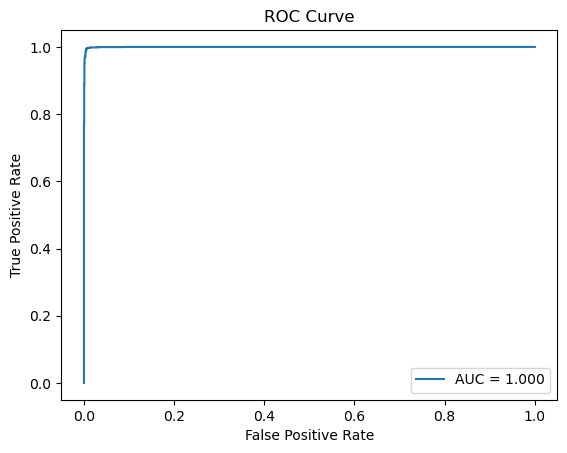

[2.25674748e-02 2.33864297e-03 2.38455090e-03 6.03894821e-05
 9.99920987e-01 9.95501758e-01 9.97063651e-01 9.26769989e-04
 8.54276565e-04 9.98415606e-01]


In [35]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(yval, ypred_proba)

auc = roc_auc_score(yval, ypred_proba)


plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
print(ypred_proba[:10])

In [36]:
print('test accuracy: {0:.6f}'.format(metrics.accuracy_score(ytest, lgb.predict(Xtest))))

test accuracy: 0.992750


In [37]:
print(smis[in_out_sub[13103]])

['BrC1=CC=C(C#N)C=C1' 'C(#N)C1=CC=C(C=C1)B(O)O']


Finally the strychnine patways were prepared and their fingerprints were determinated. The prediction of probability that given reaction is of class 1 was conducted on all of the pathways reactions.

In [38]:
from rdkit import Chem
from rdkit.Chem import inchi
from rdkit.Chem import rdFingerprintGenerator


In [39]:
import csv
import tqdm
def get_biggest_reactant_and_product(rxnsmiles):
    generateFp = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
    r,_,p = rxnsmiles.split(">")
    reactant_smi = sorted(r.split("."),key=lambda x:len(x))[-1]
    product_smi = sorted(p.split("."),key=lambda x:len(x))[-1]
    reactant_fp = generateFp.GetFingerprint(Chem.MolFromSmiles(reactant_smi))
    product_fp = generateFp.GetFingerprint(Chem.MolFromSmiles(product_smi))
    if reactant_fp==product_fp:
        print("product = reactant. skipping")
        #1=0
    return reactant_fp,product_fp




In [40]:
reactions = []
with open('woodward.txt', newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=',', quotechar='"')
    for row in tqdm.tqdm(reader):
        try:
            reactions.append(get_biggest_reactant_and_product(row[0]))
        except:
            print("problem for",row[0])

29it [00:00, 370.79it/s]


In [41]:
woodward = np.array(reactions)
print(woodward.shape)
woodward=np.concatenate([woodward[:, 0, :], woodward[:, 1, :]], axis=1)
print(woodward.shape)
woodward = pd.DataFrame(woodward)


(29, 2, 2048)
(29, 4096)


In [42]:
woodward_pred=lgb.predict_proba(woodward)[:,1]
print(woodward_pred)

[4.43281850e-03 5.60605251e-03 5.34101032e-04 4.76738438e-03
 2.06016803e-04 5.64802135e-03 2.96481945e-03 7.06935118e-03
 4.68428453e-03 2.11278546e-02 9.37845964e-03 1.04200667e-02
 1.97690686e-02 3.20615774e-03 4.95236034e-03 3.53639298e-04
 6.49106960e-02 4.89194103e-03 5.25947679e-03 1.30080446e-02
 3.58260766e-03 5.00760157e-04 7.59462760e-04 2.76203602e-02
 7.92602933e-02 1.54799758e-02 4.12319323e-02 2.23029828e-01
 2.83526778e-01]


In [43]:
reactions = []
with open('magnus.txt', newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=',', quotechar='"')
    for row in tqdm.tqdm(reader):
        try:
            reactions.append(get_biggest_reactant_and_product(row[0]))
        except:
            print("problem for",row[0])
magnus = np.array(reactions)
print(magnus.shape)
magnus=np.concatenate([magnus[:, 0, :], magnus[:, 1, :]], axis=1)
print(magnus.shape)
magnus = pd.DataFrame(magnus)
magnus_pred=lgb.predict_proba(magnus)[:,1]
print(magnus_pred)

28it [00:00, 474.82it/s]

product = reactant. skipping
(28, 2, 2048)
(28, 4096)
[7.74717868e-02 1.32146433e-02 2.85534896e-02 2.23776836e-03
 1.55455650e-03 5.83107481e-03 4.85026663e-02 1.11284849e-01
 1.41627715e-04 1.58321252e-02 1.44659530e-03 9.94941644e-03
 4.07131188e-02 3.69912007e-02 5.69247127e-02 1.29398352e-01
 5.07383662e-01 2.57741302e-01 7.65987353e-01 7.62348956e-01
 3.20924073e-01 7.74958412e-01 7.79640225e-01 8.36599827e-01
 6.79191774e-01 3.18602305e-01 3.14952562e-01 2.98933030e-01]


In [44]:
reactions = []
with open('kuehne.txt', newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=',', quotechar='"')
    for row in tqdm.tqdm(reader):
        try:
            reactions.append(get_biggest_reactant_and_product(row[0]))
        except:
            print("problem for",row[0])
kuehne = np.array(reactions)
print(kuehne.shape)
kuehne=np.concatenate([kuehne[:, 0, :], kuehne[:, 1, :]], axis=1)
print(kuehne.shape)
kuehne = pd.DataFrame(kuehne)
kuehne_pred=lgb.predict_proba(kuehne)[:,1]
print(kuehne_pred)

18it [00:00, 177.57it/s]

(18, 2, 2048)
(18, 4096)
[1.32389687e-03 1.91139478e-03 6.53309109e-03 4.02772602e-03
 4.59585007e-02 6.56659676e-02 6.19955155e-04 1.88678716e-03
 2.77352293e-02 1.78320093e-01 1.30016883e-02 1.56981176e-02
 8.88544314e-02 3.13779064e-02 7.34760055e-02 7.72809063e-01
 9.08886392e-02 2.83526778e-01]


In [45]:
reactions = []
with open('overman.txt', newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=',', quotechar='"')
    for row in tqdm.tqdm(reader):
        try:
            reactions.append(get_biggest_reactant_and_product(row[0]))
        except:
            print("problem for",row[0])
overman = np.array(reactions)
print(overman.shape)
overman=np.concatenate([overman[:, 0, :], overman[:, 1, :]], axis=1)
print(overman.shape)
overman = pd.DataFrame(overman)
overman_pred=lgb.predict_proba(overman)[:,1]
print(overman_pred)

24it [00:00, 832.40it/s]

product = reactant. skipping
(24, 2, 2048)
(24, 4096)
[0.00518902 0.02064209 0.01285196 0.01135459 0.36417921 0.04298845
 0.05735221 0.00586229 0.03403884 0.07252024 0.01342813 0.00060438
 0.0020117  0.00797815 0.00264748 0.00061053 0.01083871 0.02905346
 0.1383822  0.46609701 0.48974793 0.40155699 0.14564568 0.29893303]


In [46]:
reactions = []
with open('kuehne98.txt', newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=',', quotechar='"')
    for row in tqdm.tqdm(reader):
        try:
            reactions.append(get_biggest_reactant_and_product(row[0]))
        except:
            print("problem for",row[0])
kuehne98 = np.array(reactions)
print(kuehne98.shape)
kuehne98=np.concatenate([kuehne98[:, 0, :], kuehne98[:, 1, :]], axis=1)
print(kuehne98.shape)
kuehne98 = pd.DataFrame(kuehne98)
kuehne98_pred=lgb.predict_proba(kuehne98)[:,1]
print(kuehne98_pred)

21it [00:00, 480.55it/s]

product = reactant. skipping
(21, 2, 2048)
(21, 4096)
[6.65079503e-03 3.11239036e-04 1.77462865e-02 2.34206160e-02
 1.30921805e-02 1.30317415e-02 1.92807679e-03 2.15357650e-04
 6.70004269e-04 8.72114228e-04 3.05660136e-03 8.39921950e-04
 2.78500243e-04 3.39637412e-03 1.12390142e-01 1.82967752e-01
 4.77376471e-02 4.89747929e-01 4.01556992e-01 1.45645684e-01
 2.98933030e-01]


In [47]:
reactions = []
with open('rawal.txt', newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=',', quotechar='"')
    for row in tqdm.tqdm(reader):
        try:
            reactions.append(get_biggest_reactant_and_product(row[0]))
        except:
            print("problem for",row[0])
rawal = np.array(reactions)
print(rawal.shape)
rawal=np.concatenate([rawal[:, 0, :], rawal[:, 1, :]], axis=1)
print(rawal.shape)
rawal = pd.DataFrame(rawal)
rawal_pred=lgb.predict_proba(rawal)[:,1]
print(rawal_pred)

15it [00:00, 401.38it/s]

(15, 2, 2048)
(15, 4096)
[8.81339999e-03 7.45120806e-04 6.13377967e-01 8.78042166e-03
 2.04842737e-01 6.27964372e-02 3.26596462e-02 1.01522467e-01
 8.37625863e-01 4.02304367e-02 1.74781399e-02 7.58434841e-02
 1.42680483e-01 5.68092738e-01 2.83526778e-01]


In [48]:
reactions = []
with open('bosch.txt', newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=',', quotechar='"')
    for row in tqdm.tqdm(reader):
        try:
            reactions.append(get_biggest_reactant_and_product(row[0]))
        except:
            print("problem for",row[0])
bosch = np.array(reactions)
print(bosch.shape)
bosch=np.concatenate([bosch[:, 0, :], bosch[:, 1, :]], axis=1)
print(bosch.shape)
bosch = pd.DataFrame(bosch)
bosch_pred=lgb.predict_proba(bosch)[:,1]
print(bosch_pred)

14it [00:00, 1023.52it/s]

product = reactant. skipping
(14, 2, 2048)
(14, 4096)
[0.00842776 0.08132005 0.19194284 0.21017032 0.12205647 0.08207245
 0.02638036 0.04253454 0.03030703 0.16452457 0.41256746 0.40155699
 0.14564568 0.29893303]


In [49]:
reactions = []
with open('volhardt.txt', newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=',', quotechar='"')
    for row in tqdm.tqdm(reader):
        try:
            reactions.append(get_biggest_reactant_and_product(row[0]))
        except:
            print("problem for",row[0])
volhardt = np.array(reactions)
print(volhardt.shape)
volhardt=np.concatenate([volhardt[:, 0, :], volhardt[:, 1, :]], axis=1)
print(volhardt.shape)
volhardt = pd.DataFrame(volhardt)
volhardt_pred=lgb.predict_proba(volhardt)[:,1]
print(volhardt_pred)

13it [00:00, 374.30it/s]

(13, 2, 2048)
(13, 4096)
[2.75887563e-01 3.13460077e-02 4.68680457e-03 4.99228551e-03
 3.49409127e-02 4.55093874e-04 9.35395747e-04 8.20671209e-03
 1.06868281e-01 8.37128716e-03 2.81174084e-02 6.24913143e-01
 3.24261020e-01]


In [50]:
reactions = []
with open('martin.txt', newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=',', quotechar='"')
    for row in tqdm.tqdm(reader):
        try:
            reactions.append(get_biggest_reactant_and_product(row[0]))
        except:
            print("problem for",row[0])
martin = np.array(reactions)
print(martin.shape)
martin=np.concatenate([martin[:, 0, :], martin[:, 1, :]], axis=1)
print(martin.shape)
martin = pd.DataFrame(martin)
martin_pred=lgb.predict_proba(martin)[:,1]
print(martin_pred)

15it [00:00, 777.46it/s]

product = reactant. skipping
(15, 2, 2048)
(15, 4096)
[0.24435131 0.01203943 0.01327461 0.0197145  0.00319578 0.00090761
 0.00491823 0.02999395 0.07777244 0.04174967 0.5957208  0.48974793
 0.40155699 0.14564568 0.29893303]


In [51]:
reactions = []
with open('bodwell.txt', newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=',', quotechar='"')
    for row in tqdm.tqdm(reader):
        try:
            reactions.append(get_biggest_reactant_and_product(row[0]))
        except:
            print("problem for",row[0])
bodwell = np.array(reactions)
print(woodward.shape)
bodwell=np.concatenate([bodwell[:, 0, :], bodwell[:, 1, :]], axis=1)
print(bodwell.shape)
bodwell = pd.DataFrame(bodwell)
bodwell_pred=lgb.predict_proba(bodwell)[:,1]
print(bodwell_pred)

12it [00:00, 1396.36it/s]

(29, 4096)
(12, 4096)
[0.70728945 0.83328826 0.00095422 0.68676335 0.23886382 0.07217233
 0.10024953 0.00155677 0.07584348 0.14268048 0.56809274 0.28352678]


In [52]:
reactions = []
with open('Shibasaki.txt', newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=',', quotechar='"')
    for row in tqdm.tqdm(reader):
        try:
            reactions.append(get_biggest_reactant_and_product(row[0]))
        except:
            print("problem for",row[0])
Shibasaki = np.array(reactions)
print(Shibasaki.shape)
Shibasaki=np.concatenate([Shibasaki[:, 0, :], Shibasaki[:, 1, :]], axis=1)
print(Shibasaki.shape)
Shibasaki = pd.DataFrame(Shibasaki)
Shibasaki_pred=lgb.predict_proba(Shibasaki)[:,1]
print(Shibasaki_pred)

31it [00:00, 552.59it/s]

product = reactant. skipping
(31, 2, 2048)
(31, 4096)
[0.03703637 0.86595832 0.52987797 0.68888363 0.16132095 0.10524854
 0.0108174  0.19216289 0.00210773 0.0188412  0.01522621 0.00740325
 0.00259609 0.00577863 0.00961461 0.00266234 0.0041994  0.0014634
 0.00258884 0.02129112 0.00818484 0.16363921 0.01486652 0.94456463
 0.11798095 0.95753913 0.39021008 0.236056   0.17823638 0.6328323
 0.29893303]


In [53]:
reactions = []
with open('fukuyama.txt', newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=',', quotechar='"')
    for row in tqdm.tqdm(reader):
        try:
            reactions.append(get_biggest_reactant_and_product(row[0]))
        except:
            print("problem for",row[0])
fukuyama = np.array(reactions)
print(fukuyama.shape)
fukuyama=np.concatenate([fukuyama[:, 0, :], fukuyama[:, 1, :]], axis=1)
print(fukuyama.shape)
fukuyama = pd.DataFrame(fukuyama)
fukuyama_pred=lgb.predict_proba(fukuyama)[:,1]
print(fukuyama_pred)

29it [00:00, 1401.98it/s]

product = reactant. skipping
product = reactant. skipping
(29, 2, 2048)
(29, 4096)
[1.52128252e-03 8.22397600e-01 4.21873924e-01 7.51685231e-01
 9.03152167e-01 1.17136343e-02 4.02155691e-02 1.19776015e-01
 5.47494708e-03 1.61873421e-01 6.85259492e-01 7.98315251e-01
 7.36988872e-01 7.79551729e-01 3.90888759e-01 2.12286601e-02
 4.34552091e-02 2.49365926e-03 4.40974861e-04 1.73526205e-04
 1.54982103e-04 1.46943770e-04 3.53758061e-04 3.57170394e-04
 4.77376471e-02 4.89747929e-01 4.01556992e-01 1.45645684e-01
 2.98933030e-01]


In [54]:
reactions = []
with open('mori.txt', newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=',', quotechar='"')
    for row in tqdm.tqdm(reader):
        try:
            reactions.append(get_biggest_reactant_and_product(row[0]))
        except:
            print("problem for",row[0])
mori = np.array(reactions)
print(mori.shape)
mori=np.concatenate([mori[:, 0, :], mori[:, 1, :]], axis=1)
print(mori.shape)
mori = pd.DataFrame(mori)
mori_pred=lgb.predict_proba(mori)[:,1]
print(mori_pred)

22it [00:00, 492.06it/s]

(22, 2, 2048)
(22, 4096)
[0.93587966 0.74777473 0.83589051 0.95986529 0.55167569 0.60877448
 0.95748358 0.7561621  0.14516406 0.54909516 0.49098072 0.15910617
 0.20149301 0.15842371 0.02685031 0.17507434 0.0047858  0.04542291
 0.07654001 0.51622279 0.56809274 0.28352678]


In [55]:
reactions = []
with open('padwa.txt', newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=',', quotechar='"')
    for row in tqdm.tqdm(reader):
        try:
            reactions.append(get_biggest_reactant_and_product(row[0]))
        except:
            print("problem for",row[0])
padwa = np.array(reactions)
print(padwa.shape)
padwa=np.concatenate([padwa[:, 0, :], padwa[:, 1, :]], axis=1)
print(padwa.shape)
padwa = pd.DataFrame(padwa)
padwa_pred=lgb.predict_proba(padwa)[:,1]
print(padwa_pred)

17it [00:00, 1102.81it/s]

(17, 2, 2048)
(17, 4096)
[4.56362121e-03 1.07530679e-01 3.22851593e-02 8.35719707e-03
 8.60901591e-02 2.73684496e-01 2.37521921e-02 8.52412972e-04
 4.82911464e-04 1.08682085e-04 6.97566764e-02 3.04749951e-02
 5.58464624e-03 1.84316007e-02 3.69752860e-01 2.65973570e-02
 2.98933030e-01]


In [56]:
reactions = []
with open('reissing.txt', newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=',', quotechar='"')
    for row in tqdm.tqdm(reader):
        try:
            reactions.append(get_biggest_reactant_and_product(row[0]))
        except:
            print("problem for",row[0])
reissing = np.array(reactions)
print(reissing.shape)
reissing=np.concatenate([reissing[:, 0, :], reissing[:, 1, :]], axis=1)
print(reissing.shape)
reissing = pd.DataFrame(reissing)
reissing_pred=lgb.predict_proba(reissing)[:,1]
print(reissing_pred)

10it [00:00, 302.99it/s]

(10, 2, 2048)
(10, 4096)
[0.43603924 0.01401588 0.00186449 0.00802795 0.00149932 0.00155677
 0.07584348 0.14268048 0.56809274 0.28352678]


In [57]:
reactions = []
with open('andrade.txt', newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=',', quotechar='"')
    for row in tqdm.tqdm(reader):
        try:
            reactions.append(get_biggest_reactant_and_product(row[0]))
        except:
            print("problem for",row[0])
andrade = np.array(reactions)
print(andrade.shape)
andrade=np.concatenate([andrade[:, 0, :], andrade[:, 1, :]], axis=1)
print(andrade.shape)
andrade = pd.DataFrame(andrade)
andrade_pred=lgb.predict_proba(andrade)[:,1]
print(andrade_pred)

15it [00:00, 377.89it/s]

(15, 2, 2048)
(15, 4096)
[3.72041177e-03 1.61584868e-02 3.08032217e-04 9.26955164e-04
 5.82539639e-04 3.59348731e-02 1.12565313e-03 1.00269510e-03
 1.28678538e-03 3.67579988e-01 9.21449052e-02 4.55624390e-01
 2.13791497e-01 1.45645684e-01 2.98933030e-01]


In [58]:
reactions = []
with open('macmillian.txt', newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=',', quotechar='"')
    for row in tqdm.tqdm(reader):
        try:
            reactions.append(get_biggest_reactant_and_product(row[0]))
        except:
            print("problem for",row[0])
macmillian = np.array(reactions)
print(macmillian.shape)
macmillian=np.concatenate([macmillian[:, 0, :], macmillian[:, 1, :]], axis=1)
print(macmillian.shape)
macmillian = pd.DataFrame(macmillian)
macmillian_pred=lgb.predict_proba(macmillian)[:,1]
print(macmillian_pred)

12it [00:00, 843.39it/s]

(12, 2, 2048)
(12, 4096)
[1.65531129e-01 3.28792781e-03 2.79533464e-03 5.30142199e-04
 7.95836145e-03 9.99548604e-03 1.86642064e-03 6.75333485e-04
 3.84942693e-05 4.68668883e-04 8.17722872e-03 2.98933030e-01]


In [59]:
reactions = []
with open('vanderwal.txt', newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=',', quotechar='"')
    for row in tqdm.tqdm(reader):
        try:
            reactions.append(get_biggest_reactant_and_product(row[0]))
        except:
            print("problem for",row[0])
vanderwal = np.array(reactions)
print(vanderwal.shape)
vanderwal=np.concatenate([vanderwal[:, 0, :], vanderwal[:, 1, :]], axis=1)
print(vanderwal.shape)
vanderwal = pd.DataFrame(vanderwal)
vanderwal_pred=lgb.predict_proba(vanderwal)[:,1]
print(vanderwal_pred)

8it [00:00, 250.12it/s]

(8, 2, 2048)
(8, 4096)
[0.39393792 0.00076663 0.00062255 0.03164919 0.0207493  0.00355639
 0.01729767 0.29893303]
